## Load & Inspect

In [16]:
import pandas as pd,numpy as np
df = pd.read_csv("../data/raw/delivery.csv")
print(df.shape)
print(df.info())
df.head()

(1000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 91.3 KB
None


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Clean Text & Empty Strings

In [17]:
# convert empty strings or whitespace to NaN values
df = df.replace(r'^\s*$',np.nan,regex=True)

# clean text columns 
text_cols = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
for col in text_cols:
    df[col] = df[col].str.strip()



## Treat missing values


implement boxplot for numeric columns 

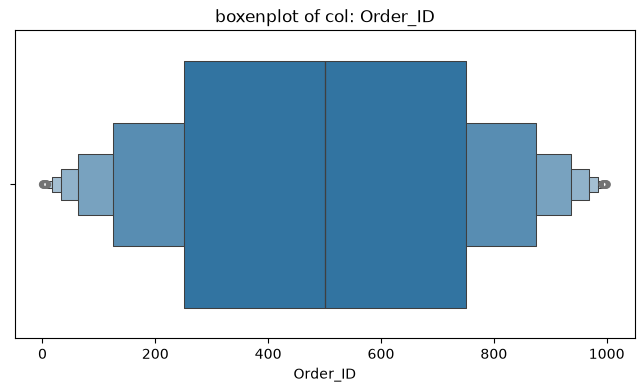

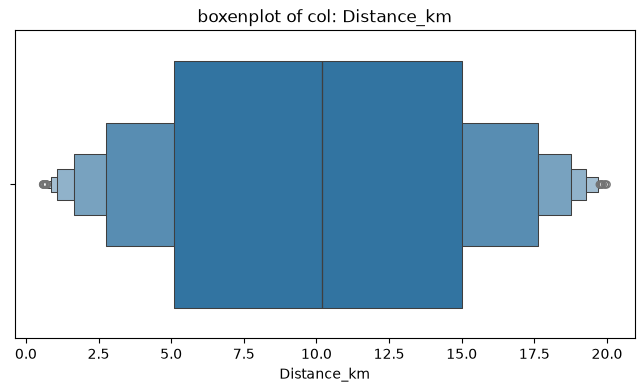

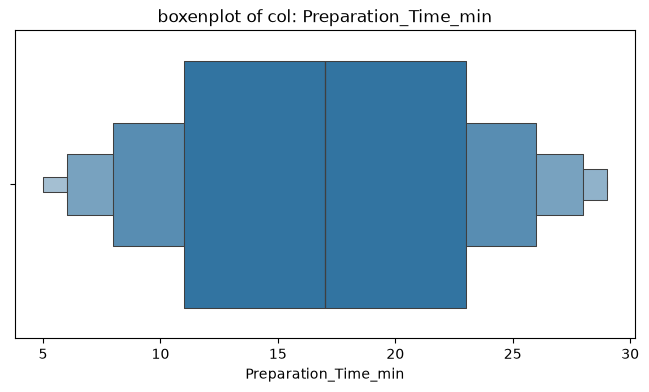

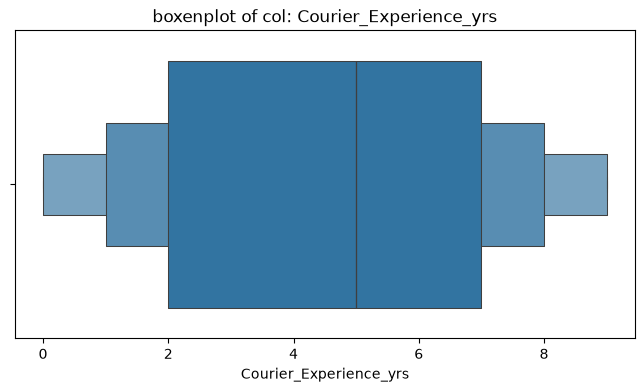

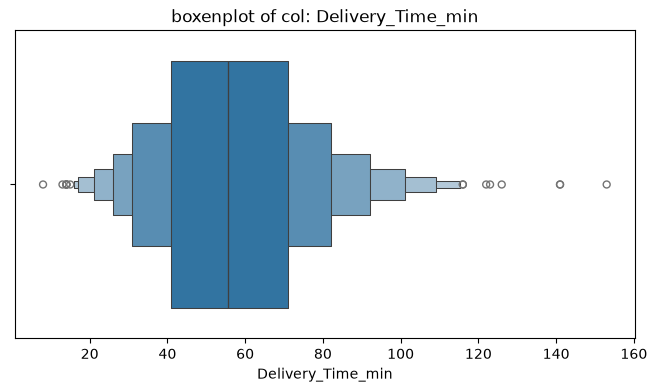

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxenplot(x = df[col])
    plt.title(f"boxenplot of col: {col}")
    plt.show()


* **Why Median:** I chose the median because some of my numerical values have extreme high scores (outliers). The average (mean) gets pulled up by these extreme numbers, while the median stays right in the middle and gives a realistic typical value.
* **Why Mode:** I chose the mode because categorical data consists of words or categories (like weather or traffic type). You cannot calculate an average for text, so filling in the blanks with the most common answer is the logical choice.

In [26]:
print(f"missing values before Treat Them: {df.isna().sum()}")

# Numeric columns -> Imput with Median value to against extrem values/outliers
num_cols = ['Distance_km','Preparation_Time_min','Courier_Experience_yrs','Delivery_Time_min']

for col in num_cols:
    df[col] = pd.to_numeric(df[col],'coerce') # (coerce) try to convert if not -> to miss value
    df[col] = df[col].fillna(df[col].median())

# category columns -> Imput with MODE (most fr category)
cat_cols = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0]) # first value in mode 

print(f"\n\nmissing value after Treat Them: {df.isna().sum()}")



missing values before Treat Them: Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


missing value after Treat Them: Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64
